# Analisis Sentimen Ulasan Shopee di Google Play Store
## Menggunakan LSTM (Long Short-Term Memory)

Pipeline: import library → load dataset → Preprocessing → EDA → Feature Extraction → Model LSTM → Evaluasi


KELOMPOK 5.
1.   Ahmad jul hadi (2301010019)
2.   Made Arya Suta wijaya (2301010030)
1.   Haura Febria Hidayah (2301010036)
2.   M. Gulwani mubaroq (2301010044)

##1. Import Library

In [ ]:
import gdown
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import os
import time
import json
import csv
import requests
from io import StringIO
from collections import Counter
from wordcloud import WordCloud
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

## 2. Load Dataset

In [ ]:
print("1. LOAD DATASET")

file_id = "1MYne5MuzcE-A9xHgM74XWdwnt2xIqLKc"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "ulasan_apk_Shoope_PlayStorev1.csv", quiet=False)

df = pd.read_csv("ulasan_apk_Shoope_PlayStorev1.csv")

print("Dataset berhasil dimuat dari Google Drive!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nKolom: {list(df.columns)}")
print(f"\n5 baris pertama:")

print(df.head())

1. LOAD DATASET


Downloading...
From: https://drive.google.com/uc?id=1MYne5MuzcE-A9xHgM74XWdwnt2xIqLKc
To: /content/ulasan_apk_Shoope_PlayStorev1.csv
100%|██████████| 6.69M/6.69M [00:00<00:00, 31.3MB/s]


Dataset berhasil dimuat dari Google Drive!
Jumlah baris: 30000
Jumlah kolom: 2

Kolom: ['Review', 'Score']

5 baris pertama:
                                              Review  Score
0  Aplikasi nya sudah sangat membantu untuk membe...      3
1  Notifikasinya dibenerin dong, sering muncul "?...      3
2  saya suka dengan gratis ongkir dan diskon,, ta...      3
3  udah pake dari lama tapi makin kesini entah ke...      4
4  suka banget aplikasinya,banyak gratis ongkir n...      5


## 3. Preprocessing


HAURA FEBRIA HIDAYAH (2301010036)

In [ ]:
print("2. DATA UNDERSTANDING")

print("\nInfo Dataset")
print(df.info())

print(f"\nMissing Values")
print(df.isnull().sum())

print(f"\nDuplikat")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

print(f"\nDistribusi Score (Rating)")
print(df['Score'].value_counts().sort_index())

print("3. DATA CLEANING")

jumlah_awal = len(df)

df = df.dropna(subset=['Review', 'Score'])
df = df.drop_duplicates(subset=['Review'])
df = df.reset_index(drop=True)

jumlah_akhir = len(df)
print(f"Data awal: {jumlah_awal}")
print(f"Data setelah cleaning: {jumlah_akhir}")
print(f"Data dihapus: {jumlah_awal - jumlah_akhir}")

2. DATA UNDERSTANDING

Info Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  30000 non-null  object
 1   Score   30000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 468.9+ KB
None

Missing Values
Review    0
Score     0
dtype: int64

Duplikat
Jumlah data duplikat: 3

Distribusi Score (Rating)
Score
1    10795
2     2573
3     2543
4     2046
5    12043
Name: count, dtype: int64
3. DATA CLEANING
Data awal: 30000
Data setelah cleaning: 29996
Data dihapus: 4


In [ ]:
print("4. CLEANING TEXT")
def cleaning_text(text):
    text = str(text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'_', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Review'].apply(cleaning_text)

print("Contoh cleaning:")
for i in range(3):
    print(f"\n  SEBELUM: {df['Review'].iloc[i][:100]}...")
    print(f"  SESUDAH: {df['clean_text'].iloc[i][:100]}...")


print("5. CASE FOLDING")
def case_folding(text):
    return text.lower()

df['case_folding'] = df['clean_text'].apply(case_folding)

print("Contoh case folding:")
for i in range(3):
    print(f"\n  SEBELUM: {df['clean_text'].iloc[i][:80]}")
    print(f"  SESUDAH: {df['case_folding'].iloc[i][:80]}")


print("\nSLANG WORD NORMALIZATION")
slang_path = 'slangWords.json'
with open(slang_path, 'r', encoding='utf-8') as f:
    slang_dict = json.load(f)

print(f"Jumlah kata slang dalam kamus: {len(slang_dict)}")

def fix_slangwords(text):
    words = text.split()
    fixed_words = []
    for word in words:
        if word.lower() in slang_dict:
            fixed_words.append(slang_dict[word.lower()])
        else:
            fixed_words.append(word)
    return ' '.join(fixed_words)

df['slang_fixed'] = df['case_folding'].apply(fix_slangwords)

print("Contoh slang normalization:")
for i in range(3):
    print(f"\n  SEBELUM: {df['case_folding'].iloc[i][:80]}")
    print(f"  SESUDAH: {df['slang_fixed'].iloc[i][:80]}")

4. CLEANING TEXT
Contoh cleaning:

  SEBELUM: Aplikasi nya sudah sangat membantu untuk membeli barang tanpa harus keluar rumah. Tapi, masih banyak...
  SESUDAH: Aplikasi nya sudah sangat membantu untuk membeli barang tanpa harus keluar rumah Tapi masih banyak k...

  SEBELUM: Notifikasinya dibenerin dong, sering muncul "? Pesanan dikirim" waktu dipencet malah kebuka barang s...
  SESUDAH: Notifikasinya dibenerin dong sering muncul Pesanan dikirim waktu dipencet malah kebuka barang seakan...

  SEBELUM: saya suka dengan gratis ongkir dan diskon,, tapi kenapa sekarang harus ada iklan video otomatis puta...
  SESUDAH: saya suka dengan gratis ongkir dan diskon tapi kenapa sekarang harus ada iklan video otomatis putar ...
5. CASE FOLDING
Contoh case folding:

  SEBELUM: Aplikasi nya sudah sangat membantu untuk membeli barang tanpa harus keluar rumah
  SESUDAH: aplikasi nya sudah sangat membantu untuk membeli barang tanpa harus keluar rumah

  SEBELUM: Notifikasinya dibenerin dong sering mun

In [ ]:
print("6. TOKENIZATION")

def tokenizing(text):
    return word_tokenize(text)

df['tokenized'] = df['slang_fixed'].apply(tokenizing)

print("Contoh tokenization:")
for i in range(3):
    tokens = df['tokenized'].iloc[i][:10]
    print(f"  [{i}] {tokens}... (total {len(df['tokenized'].iloc[i])} token)")

print("7. STOPWORD REMOVAL")

stop_words = {
    'di', 'ke', 'dari', 'pada', 'dalam', 'oleh', 'untuk',
    'dengan', 'antara', 'tentang', 'kepada', 'terhadap',
    'dan', 'atau', 'serta', 'yaitu', 'yakni', 'bahwa',
    'kita', 'mereka', 'ini', 'itu',
    'yang', 'lah', 'pun', 'per',
    'apa', 'siapa', 'mana', 'kapan',
    'nya', 'yg', 'dong', 'sih', 'loh', 'kok', 'tuh',
    'nih', 'nah', 'kan', 'deh', 'bgt',
    'gak', 'ga', 'gk', 'tp', 'krn', 'dgn', 'utk', 'jg', 'sm',
    'kalo', 'klo', 'klw', 'klu', 'gmn', 'emg', 'emang',
    'udh', 'sdh', 'blm', 'blum', 'dr', 'dri', 'pd', 'pda',
}

print(f"Total stopwords (minimal): {len(stop_words)}")

def stopword_removal(tokens):
    return [word for word in tokens if word not in stop_words and len(word) > 1]

df['stopword_removed'] = df['tokenized'].apply(stopword_removal)

print("\nContoh stopword removal:")
for i in range(3):
    before = len(df['tokenized'].iloc[i])
    after = len(df['stopword_removed'].iloc[i])
    print(f"  [{i}] {before} token -> {after} token (hapus {before - after} stopwords)")
    print(f"       {df['stopword_removed'].iloc[i][:8]}...")

print("8. FINALISASI TEKS (tanpa stemming)")

df['final_text'] = df['stopword_removed'].apply(lambda tokens: ' '.join(tokens))

before_filter = len(df)
df = df[df['final_text'].str.strip() != '']
df = df.reset_index(drop=True)
after_filter = len(df)

print(f"Data sebelum filter: {before_filter}")
print(f"Data setelah filter (hapus teks kosong): {after_filter}")
print(f"Data dihapus: {before_filter - after_filter}")

6. TOKENIZATION
Contoh tokenization:
  [0] ['aplikasi', 'nya', 'sudah', 'sangat', 'membantu', 'untuk', 'membeli', 'barang', 'tanpa', 'harus']... (total 68 token)
  [1] ['notifikasinya', 'dibenerin', 'dong', 'sering', 'muncul', 'pesanan', 'dikirim', 'waktu', 'dipencet', 'bahkan']... (total 49 token)
  [2] ['saya', 'suka', 'dengan', 'gratis', 'ongkos', 'kirim', 'dan', 'diskon', 'tapi', 'kenapa']... (total 62 token)
7. STOPWORD REMOVAL
Total stopwords (minimal): 66

Contoh stopword removal:
  [0] 68 token -> 55 token (hapus 13 stopwords)
       ['aplikasi', 'sudah', 'sangat', 'membantu', 'membeli', 'barang', 'tanpa', 'harus']...
  [1] 49 token -> 42 token (hapus 7 stopwords)
       ['notifikasinya', 'dibenerin', 'sering', 'muncul', 'pesanan', 'dikirim', 'waktu', 'dipencet']...
  [2] 62 token -> 55 token (hapus 7 stopwords)
       ['saya', 'suka', 'gratis', 'ongkos', 'kirim', 'diskon', 'tapi', 'kenapa']...
8. FINALISASI TEKS (tanpa stemming)
Data sebelum filter: 29996
Data setelah filter (

In [ ]:
print("\nContoh teks final:")
for i in range(3):
    print(f"  [{i}] {df['final_text'].iloc[i][:100]}...")

print("9. LABELING SENTIMEN (Lexicon-Based, Cleaned InSet)")

lexicon_path = os.path.join('/content/', 'output', 'lexicon_inset_cleaned.json')

print("Downloading lexicon InSet dari GitHub...")
lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        if len(row) >= 2:
            lexicon_positive[row[0]] = int(row[1])

lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        if len(row) >= 2:
            lexicon_negative[row[0]] = int(row[1])

print(f"Lexicon ASLI (sebelum cleaning):")
print(f"  Positif: {len(lexicon_positive)} kata")
print(f"  Negatif: {len(lexicon_negative)} kata")

conflict_words = set(lexicon_positive.keys()) & set(lexicon_negative.keys())
print(f"  Kata konflik (ada di kedua kamus): {len(conflict_words)}")

for word in conflict_words:
    del lexicon_negative[word]

print(f"\nLexicon BERSIH (setelah cleaning):")
print(f"  Positif: {len(lexicon_positive)} kata (tidak berubah)")
print(f"  Negatif: {len(lexicon_negative)} kata (berkurang {len(conflict_words)})")
print(f"  Kata konflik: 0 (semua sudah dihapus dari negatif)")

ambiguous_words = {
    'tapi', 'tetapi', 'namun', 'akan', 'walau', 'walaupun',
    'meski', 'meskipun', 'kendati', 'cuma', 'cuman', 'hanya',
    'padahal', 'sedangkan', 'melainkan', 'sebaliknya',
    'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'tak',
    'bukan', 'belum', 'tiada',
    'sangat', 'sekali', 'amat', 'paling', 'terlalu', 'sungguh',
    'begitu', 'banget', 'agak', 'kurang', 'lumayan',
    'biasa', 'cukup', 'sudah', 'masih', 'bisa', 'ada',
    'jadi', 'juga', 'saja', 'lagi', 'pernah',
}

removed_from_pos = 0
removed_from_neg = 0
for w in ambiguous_words:
    if w in lexicon_positive:
        del lexicon_positive[w]
        removed_from_pos += 1
    if w in lexicon_negative:
        del lexicon_negative[w]
        removed_from_neg += 1


Contoh teks final:
  [0] aplikasi sudah sangat membantu membeli barang tanpa harus keluar rumah tapi masih banyak kekurangan ...
  [1] notifikasinya dibenerin sering muncul pesanan dikirim waktu dipencet bahkan kebuka barang seakan not...
  [2] saya suka gratis ongkos kirim diskon tapi kenapa sekarang harus ada iklan video otomatis putar saat ...
9. LABELING SENTIMEN (Lexicon-Based, Cleaned InSet)
Lexicon ASLI (sebelum cleaning):
  Positif: 3609 kata
  Negatif: 6607 kata
  Kata konflik (ada di kedua kamus): 1142

Lexicon BERSIH (setelah cleaning):
  Positif: 3609 kata (tidak berubah)
  Negatif: 5465 kata (berkurang 1142)
  Kata konflik: 0 (semua sudah dihapus dari negatif)


In [ ]:
print("LABELING BERDASARKAN RATING")

def rating_to_sentiment(score):

    if score <= 2:
        return "negatif"

    elif score == 3:
        return "netral"

    else:
        return "positif"

df["rating_sentiment"] = (
    df["Score"]
    .apply(rating_to_sentiment)
)

print("\nDistribusi Rating Sentiment:")

print(
    df["rating_sentiment"]
    .value_counts()
)

LABELING BERDASARKAN RATING

Distribusi Rating Sentiment:
rating_sentiment
positif    14066
negatif    13365
netral      2543
Name: count, dtype: int64


In [ ]:
print("PERBANDINGAN LEXICON VS RATING")

def rating_to_sentiment(score):
    if score <= 2: return "negatif"
    elif score == 3: return "netral"
    else: return "positif"

def label_sentiment_lexicon(normalized_score):
    threshold = 0.2
    if normalized_score > threshold: return 'positif'
    elif normalized_score < -threshold: return 'negatif'
    else: return 'netral'

# Cek dan hitung ulang jika kolom hilang (akibat load csv)
if 'polarity_normalized' not in df.columns:
    def calc_score(text):
        if not isinstance(text, str): return 0.0
        words = text.split()
        if not words: return 0.0
        score = sum(lexicon_positive.get(w, 0) + lexicon_negative.get(w, 0) for w in words)
        return score / len(words)

    df['polarity_normalized'] = df['final_text'].apply(calc_score)

# Generate label jika belum ada
if 'sentiment' not in df.columns:
    df['sentiment'] = df['polarity_normalized'].apply(label_sentiment_lexicon)

if 'rating_sentiment' not in df.columns:
    df['rating_sentiment'] = df['Score'].apply(rating_to_sentiment)

# Tampilkan Perbandingan
comparison = pd.crosstab(
    df["rating_sentiment"],
    df["sentiment"],
    margins=True
)

print(comparison)

agreement = (df["rating_sentiment"] == df["sentiment"]).mean() * 100
print(f"\nTingkat Kesesuaian: {agreement:.2f}%")

PERBANDINGAN LEXICON VS RATING
sentiment         negatif  netral  positif    All
rating_sentiment                                 
negatif              3282    5153     4930  13365
netral                501     875     1167   2543
positif              1125    2759    10182  14066
All                  4908    8787    16279  29974

Tingkat Kesesuaian: 47.84%


In [ ]:
print(f"\nKata ambigu dihapus dari lexicon:")
print(f"  Dari positif: {removed_from_pos} kata")
print(f"  Dari negatif: {removed_from_neg} kata")
print(f"  Total kata ambigu yang di-netralisasi: {len(ambiguous_words)}")

print(f"\nVerifikasi kata setelah cleaning:")
test_words = ['bagus', 'cocok', 'suka', 'lumayan', 'cepat', 'murah', 'sempurna',
              'tapi', 'tetapi', 'namun', 'tidak', 'sangat', 'biasa', 'cukup']
for w in test_words:
    pos = lexicon_positive.get(w, None)
    neg = lexicon_negative.get(w, None)
    status = "NETRAL (tidak di kamus)" if pos is None and neg is None else f"positif={pos}, negatif={neg}"
    print(f"  '{w}': {status}")

print(f"\nLexicon FINAL:")
print(f"  Positif: {len(lexicon_positive)} kata")
print(f"  Negatif: {len(lexicon_negative)} kata")

os.makedirs(os.path.dirname(lexicon_path), exist_ok=True)
with open(lexicon_path, 'w') as f:
    json.dump({'positive': lexicon_positive, 'negative': lexicon_negative}, f, ensure_ascii=False)
print(f"Lexicon bersih disimpan ke: {lexicon_path}")

def calc_lexicon_score(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0, 0
    words = text.split()
    if len(words) == 0:
        return 0.0, 0

    score = 0
    for word in words:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        elif word in lexicon_negative:
            score += lexicon_negative[word]

    return score / len(words), score

print("\nMenghitung polarity score...")
results = df['final_text'].apply(calc_lexicon_score)
df['polarity_normalized'] = [r[0] for r in results]
df['polarity_raw'] = [r[1] for r in results]

print(f"\nStatistik Normalized Score:")
print(f"  Mean:   {df['polarity_normalized'].mean():.4f}")
print(f"  Median: {df['polarity_normalized'].median():.4f}")
print(f"  Std:    {df['polarity_normalized'].std():.4f}")

THRESHOLD = 0.2

def label_sentiment_lexicon(normalized_score):
    if normalized_score > THRESHOLD:
        return 'positif'
    elif normalized_score < -THRESHOLD:
        return 'negatif'
    else:
        return 'netral'

df['sentiment'] = df['polarity_normalized'].apply(label_sentiment_lexicon)


Kata ambigu dihapus dari lexicon:
  Dari positif: 10 kata
  Dari negatif: 15 kata
  Total kata ambigu yang di-netralisasi: 45

Verifikasi kata setelah cleaning:
  'bagus': positif=2, negatif=None
  'cocok': positif=4, negatif=None
  'suka': positif=3, negatif=None
  'lumayan': NETRAL (tidak di kamus)
  'cepat': positif=3, negatif=None
  'murah': positif=3, negatif=None
  'sempurna': positif=3, negatif=None
  'tapi': NETRAL (tidak di kamus)
  'tetapi': NETRAL (tidak di kamus)
  'namun': NETRAL (tidak di kamus)
  'tidak': NETRAL (tidak di kamus)
  'sangat': NETRAL (tidak di kamus)
  'biasa': NETRAL (tidak di kamus)
  'cukup': NETRAL (tidak di kamus)

Lexicon FINAL:
  Positif: 3599 kata
  Negatif: 5450 kata
Lexicon bersih disimpan ke: /content/output/lexicon_inset_cleaned.json

Menghitung polarity score...

Statistik Normalized Score:
  Mean:   0.3250
  Median: 0.2593
  Std:    0.6165


In [ ]:
print("\nDistribusi Sentimen:")
print(df['sentiment'].value_counts())

print("\nPersentase Sentimen:")
print(
    round(
        df['sentiment'].value_counts(normalize=True) * 100,
        2
    )
)


Distribusi Sentimen:
sentiment
positif    16279
netral      8787
negatif     4908
Name: count, dtype: int64

Persentase Sentimen:
sentiment
positif    54.31
netral     29.32
negatif    16.37
Name: proportion, dtype: float64


In [ ]:
print("LABEL BERDASARKAN RATING")

def rating_to_sentiment(score):

    if score <= 2:
        return "negatif"

    elif score == 3:
        return "netral"

    else:
        return "positif"

df["rating_sentiment"] = df["Score"].apply(
    rating_to_sentiment
)

print(
    df["rating_sentiment"]
    .value_counts()
)

LABEL BERDASARKAN RATING
rating_sentiment
positif    14066
negatif    13365
netral      2543
Name: count, dtype: int64


In [ ]:
print(f"\nThreshold: +/-{THRESHOLD}")
print(f"\nDistribusi sentimen (Lexicon-Based, Cleaned):")
for label, count in df['sentiment'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")

bagus_reviews = df[df['final_text'].str.contains('bagus', na=False)]
print(f"\nVerifikasi - review mengandung 'bagus' ({len(bagus_reviews)} total):")
for label, count in bagus_reviews['sentiment'].value_counts().items():
    print(f"  {label}: {count}")

print("10. SIMPAN DATASET PREPROCESSED")

final_columns = ['Review', 'Score', 'sentiment', 'clean_text', 'final_text',
                 'polarity_normalized', 'polarity_raw']
final_df = df[final_columns].copy()


output_path = '/content/dataset_preprocessed.csv'
final_df.to_csv(output_path, index=False)

print(f"Dataset preprocessed disimpan ke: {output_path}")
print(f"Jumlah data final: {len(final_df)}")
print(f"\nDistribusi sentimen final:")
print(final_df['sentiment'].value_counts())
print(f"\nContoh data final:")
print(final_df[['final_text', 'sentiment', 'polarity_normalized']].head(10))


Threshold: +/-0.2

Distribusi sentimen (Lexicon-Based, Cleaned):
  positif: 16279 (54.3%)
  netral: 8787 (29.3%)
  negatif: 4908 (16.4%)

Verifikasi - review mengandung 'bagus' (4542 total):
  positif: 2890
  netral: 1180
  negatif: 472
10. SIMPAN DATASET PREPROCESSED
Dataset preprocessed disimpan ke: /content/dataset_preprocessed.csv
Jumlah data final: 29974

Distribusi sentimen final:
sentiment
positif    16279
netral      8787
negatif     4908
Name: count, dtype: int64

Contoh data final:
                                          final_text sentiment  \
0  aplikasi sudah sangat membantu membeli barang ...    netral   
1  notifikasinya dibenerin sering muncul pesanan ...   positif   
2  saya suka gratis ongkos kirim diskon tapi kena...    netral   
3  sudah pakai lama tapi makin kesini entah kenap...    netral   
4  suka banget aplikasinya banyak gratis ongkos k...   positif   
5  aplikasinya lambat sekali dibagian menu profil...    netral   
6  jelek banget sekarang ui jelek kebany

## 4. Exploratory Data Analysis (EDA)



M.GULWANI MUBAROQ (2301010044)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import pickle
import os
import json

print("LOADING DATASET PREPROCESSED")

base_dir = '/content/'
dataset_path = os.path.join(base_dir, 'dataset_preprocessed.csv')
df = pd.read_csv(dataset_path)

print(f"Dataset dimuat: {len(df)} baris")
print(f"Kolom: {list(df.columns)}")
print(df.head())

output_dir = os.path.join(base_dir, 'output')
os.makedirs(output_dir, exist_ok=True)

LOADING DATASET PREPROCESSED
Dataset dimuat: 29974 baris
Kolom: ['Review', 'Score', 'sentiment', 'clean_text', 'final_text', 'polarity_normalized', 'polarity_raw']
                                              Review  Score sentiment  \
0  Aplikasi nya sudah sangat membantu untuk membe...      3    netral   
1  Notifikasinya dibenerin dong, sering muncul "?...      3   positif   
2  saya suka dengan gratis ongkir dan diskon,, ta...      3    netral   
3  udah pake dari lama tapi makin kesini entah ke...      4    netral   
4  suka banget aplikasinya,banyak gratis ongkir n...      5   positif   

                                          clean_text  \
0  Aplikasi nya sudah sangat membantu untuk membe...   
1  Notifikasinya dibenerin dong sering muncul Pes...   
2  saya suka dengan gratis ongkir dan diskon tapi...   
3  udah pake dari lama tapi makin kesini entah ke...   
4  suka banget aplikasinya banyak gratis ongkir n...   

                                          final_text  polari


EDA 1: DISTRIBUSI SENTIMEN

Distribusi sentimen hasil pelabelan:
Positif   : 16,279 review (54.31%)
Netral    : 8,787 review (29.32%)
Negatif   : 4,908 review (16.37%)


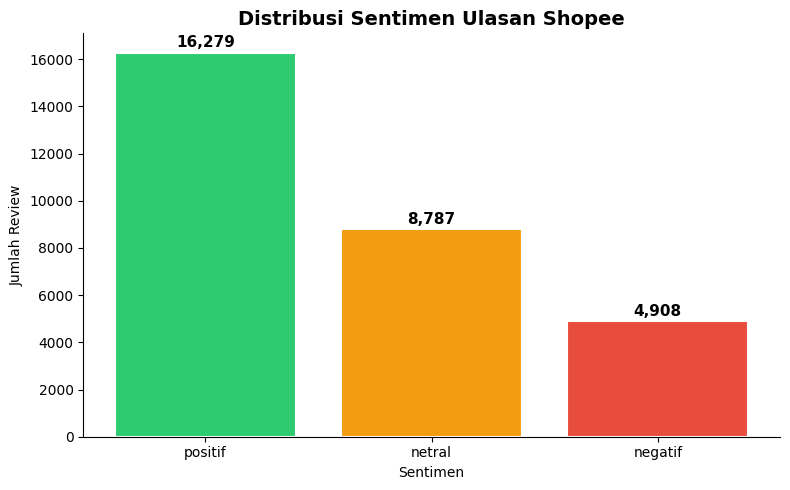

In [ ]:
print("\nEDA 1: DISTRIBUSI SENTIMEN")

sentiment_counts = df['sentiment'].value_counts()

print("\nDistribusi sentimen hasil pelabelan:")

for label, count in sentiment_counts.items():
    persen = (count / len(df)) * 100
    print(f"{label.capitalize():<10}: {count:,} review ({persen:.2f}%)")

colors = {
    'positif': '#2ecc71',
    'netral': '#f39c12',
    'negatif': '#e74c3c'
}

color_list = [colors[label] for label in sentiment_counts.index]
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=color_list,
    edgecolor='white',
    linewidth=1.5
)


for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 100,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'Distribusi Sentimen Ulasan Shopee',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah Review')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


EDA 2: DISTRIBUSI RATING

Distribusi Rating:
Rating 1 : 10,793 review (36.01%)
Rating 2 : 2,572 review (8.58%)
Rating 3 : 2,543 review (8.48%)
Rating 4 : 2,044 review (6.82%)
Rating 5 : 12,022 review (40.11%)


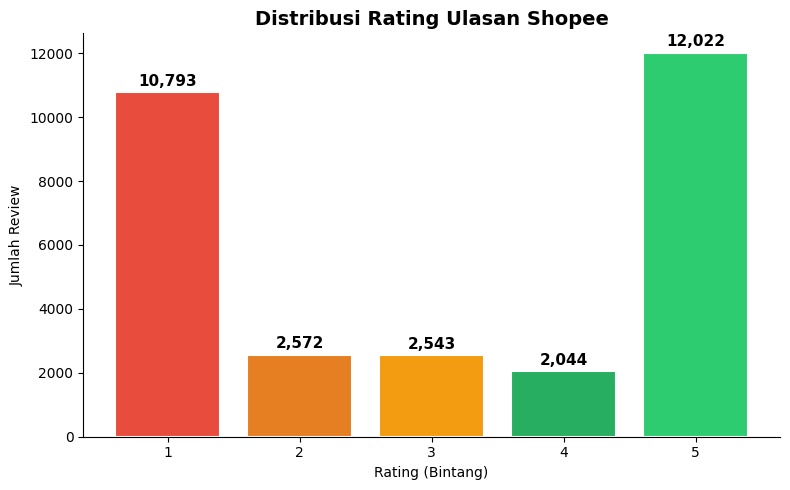

In [ ]:
print("\nEDA 2: DISTRIBUSI RATING")

rating_counts = df['Score'].value_counts().sort_index()

print("\nDistribusi Rating:")

for rating, count in rating_counts.items():
    persen = (count / len(df)) * 100
    print(f"Rating {rating} : {count:,} review ({persen:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 5))

rating_colors = [
    '#e74c3c',
    '#e67e22',
    '#f39c12',
    '#27ae60',
    '#2ecc71'
]

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color=rating_colors,
    edgecolor='white',
    linewidth=1.5
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 100,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'Distribusi Rating Ulasan Shopee',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Rating (Bintang)')
ax.set_ylabel('Jumlah Review')
ax.set_xticks([1, 2, 3, 4, 5])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


EDA 2: DISTRIBUSI RATING

Distribusi Rating:
Rating 1: 10,793 review (36.01%)
Rating 2: 2,572 review (8.58%)
Rating 3: 2,543 review (8.48%)
Rating 4: 2,044 review (6.82%)
Rating 5: 12,022 review (40.11%)


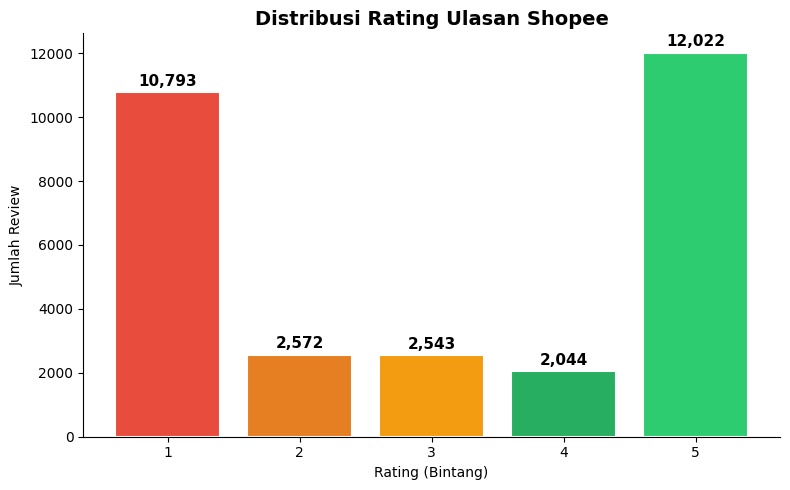


EDA 3: WORD COUNT & PANJANG REVIEW
Rata-rata panjang review : 28.7 kata
Median panjang review    : 25.0 kata
Maksimum panjang review  : 191 kata
Minimum panjang review   : 1 kata


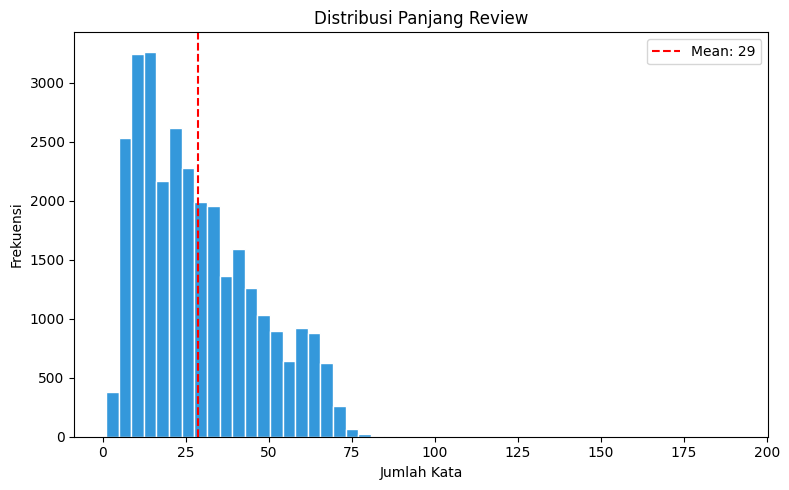

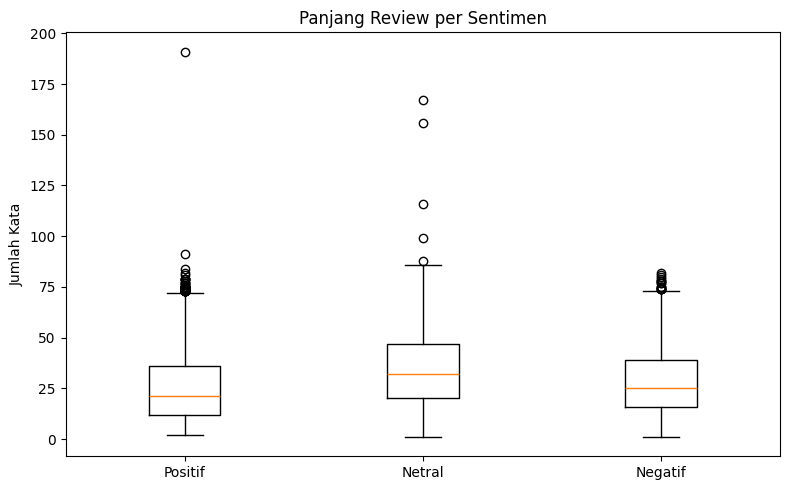

In [ ]:
print("\n" + "=" * 60)
print("EDA 2: DISTRIBUSI RATING")
print("=" * 60)

rating_counts = df['Score'].value_counts().sort_index()

print("\nDistribusi Rating:")

for rating, count in rating_counts.items():
    persen = (count / len(df)) * 100
    print(f"Rating {rating}: {count:,} review ({persen:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 5))

rating_colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71']

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color=rating_colors,
    edgecolor='white',
    linewidth=1.5
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 100,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

ax.set_title(
    'Distribusi Rating Ulasan Shopee',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Rating (Bintang)')
ax.set_ylabel('Jumlah Review')
ax.set_xticks([1, 2, 3, 4, 5])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("EDA 3: WORD COUNT & PANJANG REVIEW")
print("=" * 60)

df['word_count'] = df['final_text'].apply(
    lambda x: len(str(x).split())
)

print(f"Rata-rata panjang review : {df['word_count'].mean():.1f} kata")
print(f"Median panjang review    : {df['word_count'].median():.1f} kata")
print(f"Maksimum panjang review  : {df['word_count'].max()} kata")
print(f"Minimum panjang review   : {df['word_count'].min()} kata")

plt.figure(figsize=(8,5))

plt.hist(
    df['word_count'],
    bins=50,
    color='#3498db',
    edgecolor='white'
)

plt.axvline(
    df['word_count'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {df['word_count'].mean():.0f}"
)

plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

data_box = [
    df[df['sentiment'] == s]['word_count']
    for s in ['positif', 'netral', 'negatif']
]

plt.boxplot(
    data_box,
    tick_labels=['Positif', 'Netral', 'Negatif']
)

plt.title('Panjang Review per Sentimen')
plt.ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()


EDA 4: WORD FREQUENCY

Top 20 kata paling sering muncul:
 1. shopee          : 21,130
 2. saya            : 18,272
 3. tidak           : 14,060
 4. bisa            : 11,526
 5. ada             : 11,519
 6. sudah           : 10,507
 7. barang          : 10,473
 8. tapi            : 9,618
 9. belanja         : 9,086
10. aplikasi        : 8,464
11. lagi            : 8,248
12. kalau           : 7,465
13. sangat          : 7,406
14. juga            : 6,873
15. saja            : 6,674
16. banget          : 6,602
17. banyak          : 6,128
18. jadi            : 5,832
19. kirim           : 5,666
20. pengiriman      : 5,587


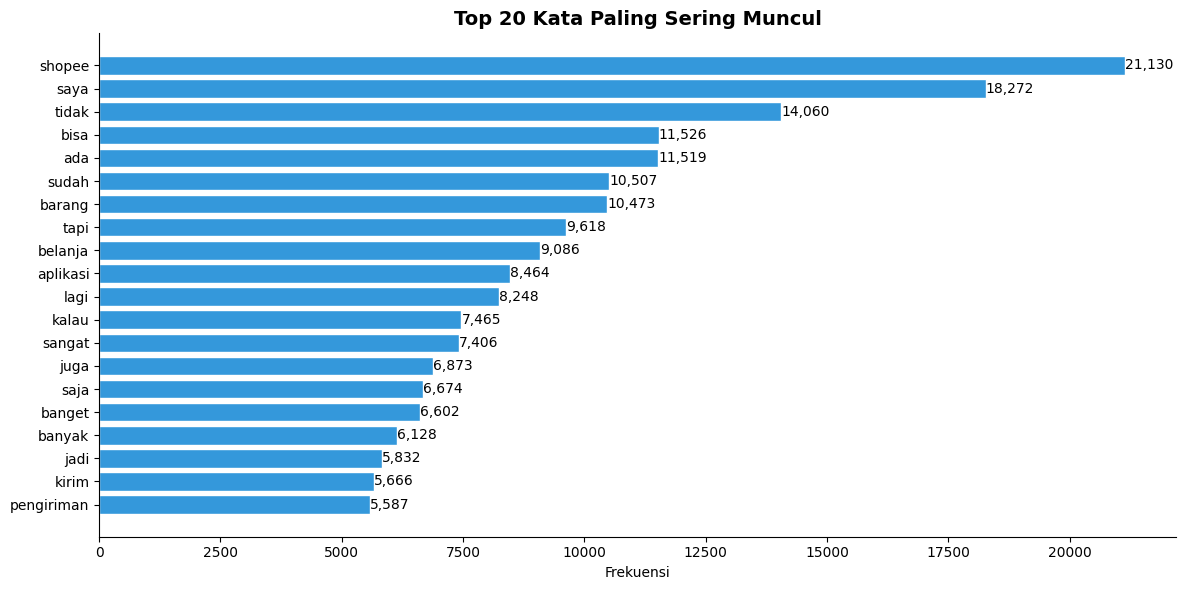

In [ ]:
print("\n" + "=" * 60)
print("EDA 4: WORD FREQUENCY")
print("=" * 60)

all_words = ' '.join(
    df['final_text'].dropna().astype(str)
).split()

word_freq = Counter(all_words)

top_20 = word_freq.most_common(20)

print("\nTop 20 kata paling sering muncul:")

for i, (word, freq) in enumerate(top_20, 1):
    print(f"{i:2d}. {word:<15} : {freq:,}")

# Grafik
words = [w for w, _ in top_20]
freqs = [f for _, f in top_20]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    range(len(words)),
    freqs,
    color='#3498db',
    edgecolor='white'
)

ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)

ax.invert_yaxis()

ax.set_title(
    'Top 20 Kata Paling Sering Muncul',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Frekuensi')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, freq in zip(bars, freqs):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{freq:,}',
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()


EDA 5: TOP KATA PER SENTIMEN

--------------------------------------------------
TOP 15 KATA SENTIMEN POSITIF
--------------------------------------------------
 1. shopee          : 11,075
 2. belanja         : 6,362
 3. tidak           : 6,061
 4. ada             : 5,659
 5. barang          : 5,467
 6. bisa            : 5,462
 7. saya            : 5,290
 8. tapi            : 4,487
 9. banyak          : 4,324
10. sangat          : 4,279
11. sudah           : 4,241
12. kirim           : 4,023
13. lagi            : 3,773
14. juga            : 3,763
15. kalau           : 3,385


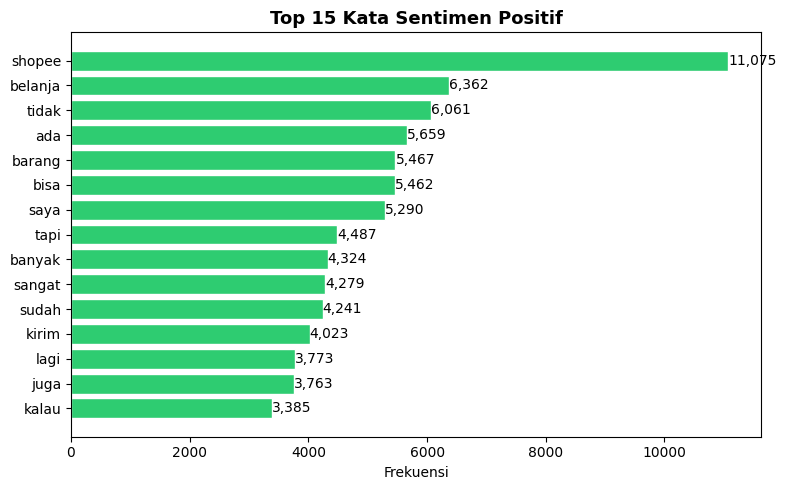


--------------------------------------------------
TOP 15 KATA SENTIMEN NETRAL
--------------------------------------------------
 1. saya            : 7,594
 2. shopee          : 6,903
 3. tidak           : 5,444
 4. sudah           : 4,236
 5. bisa            : 4,192
 6. ada             : 4,140
 7. tapi            : 3,556
 8. barang          : 3,524
 9. lagi            : 3,053
10. aplikasi        : 2,926
11. kalau           : 2,826
12. saja            : 2,497
13. juga            : 2,181
14. pengiriman      : 2,163
15. banget          : 2,159


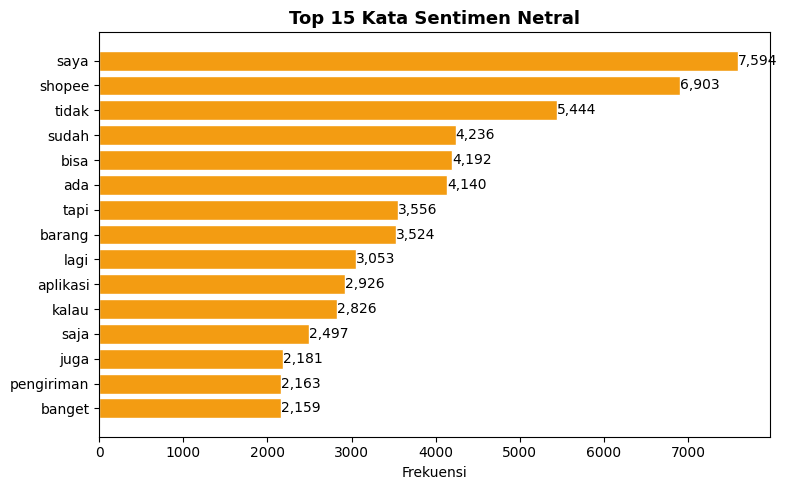


--------------------------------------------------
TOP 15 KATA SENTIMEN NEGATIF
--------------------------------------------------
 1. saya            : 5,388
 2. shopee          : 3,152
 3. tidak           : 2,555
 4. aplikasi        : 2,441
 5. sudah           : 2,030
 6. bisa            : 1,872
 7. pengiriman      : 1,834
 8. ada             : 1,720
 9. lama            : 1,628
10. tapi            : 1,575
11. barang          : 1,482
12. lagi            : 1,422
13. kalau           : 1,254
14. banget          : 1,246
15. sangat          : 1,183


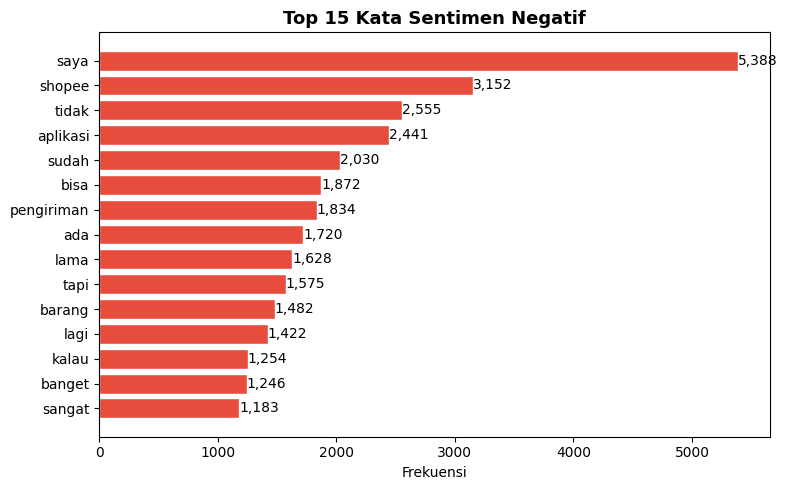

In [ ]:
print("\n" + "=" * 60)
print("EDA 5: TOP KATA PER SENTIMEN")
print("=" * 60)

sentiment_labels = ['positif', 'netral', 'negatif']
sentiment_colors = ['#2ecc71', '#f39c12', '#e74c3c']

for sentiment, color in zip(sentiment_labels, sentiment_colors):

    print("\n" + "-" * 50)
    print(f"TOP 15 KATA SENTIMEN {sentiment.upper()}")
    print("-" * 50)

    texts = df[
        df['sentiment'] == sentiment
    ]['final_text'].dropna().astype(str)

    words_list = ' '.join(texts).split()

    top_words = Counter(words_list).most_common(15)

    for i, (word, freq) in enumerate(top_words, 1):
        print(f"{i:2d}. {word:<15} : {freq:,}")

    words = [w for w, _ in top_words]
    freqs = [f for _, f in top_words]

    plt.figure(figsize=(8, 5))

    bars = plt.barh(
        range(len(words)),
        freqs,
        color=color,
        edgecolor='white'
    )

    plt.yticks(range(len(words)), words)
    plt.gca().invert_yaxis()

    plt.title(
        f'Top 15 Kata Sentimen {sentiment.capitalize()}',
        fontsize=13,
        fontweight='bold'
    )

    plt.xlabel('Frekuensi')

    for bar, freq in zip(bars, freqs):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f'{freq:,}',
            va='center'
        )

    plt.tight_layout()
    plt.show()


EDA 6: WORD CLOUD PER SENTIMEN

--------------------------------------------------
SENTIMEN POSITIF
--------------------------------------------------
Jumlah Review : 16,279


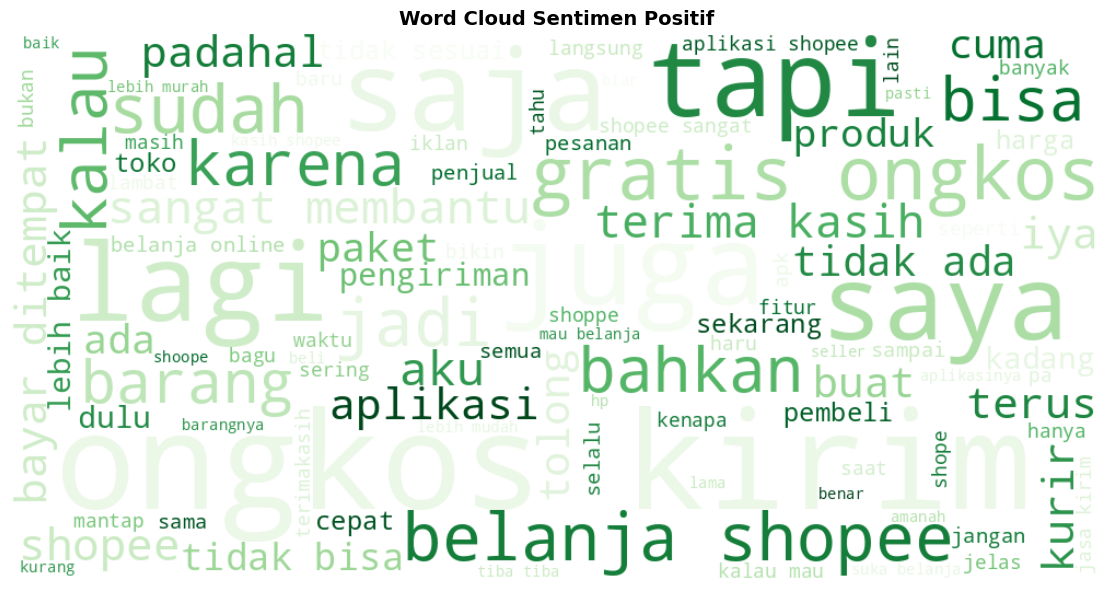


--------------------------------------------------
SENTIMEN NETRAL
--------------------------------------------------
Jumlah Review : 8,787


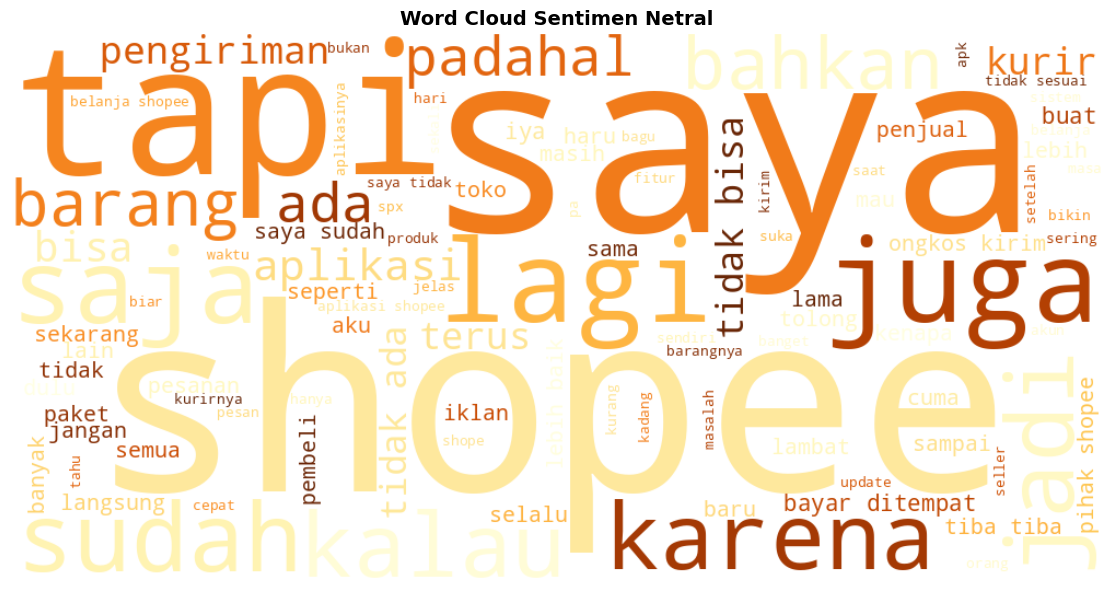


--------------------------------------------------
SENTIMEN NEGATIF
--------------------------------------------------
Jumlah Review : 4,908


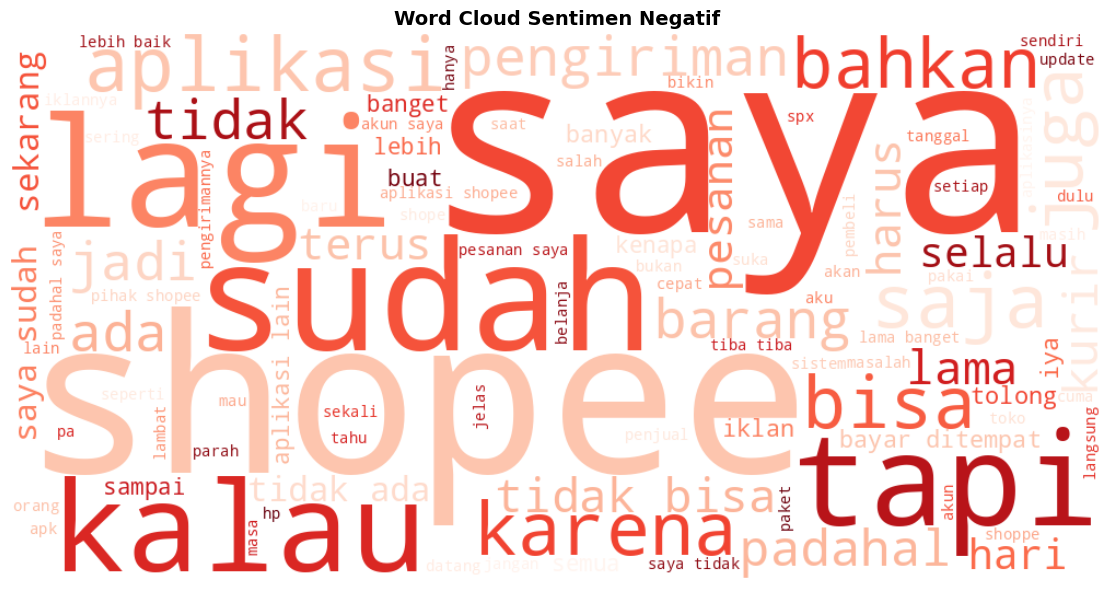

In [ ]:
print("\n" + "=" * 60)
print("EDA 6: WORD CLOUD PER SENTIMEN")
print("=" * 60)

def generate_wordcloud(sentiment_label, color_map):

    sentiment_data = df[df['sentiment'] == sentiment_label]

    total_review = len(sentiment_data)

    print("\n" + "-" * 50)
    print(f"SENTIMEN {sentiment_label.upper()}")
    print("-" * 50)
    print(f"Jumlah Review : {total_review:,}")

    text = ' '.join(
        sentiment_data['final_text']
        .dropna()
        .astype(str)
    )

    if not text.strip():
        print("Tidak ada data.")
        return

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap=color_map,
        max_words=100,
        random_state=42
    ).generate(text)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        wordcloud,
        interpolation='bilinear'
    )

    plt.title(
        f'Word Cloud Sentimen {sentiment_label.capitalize()}',
        fontsize=14,
        fontweight='bold'
    )

    plt.axis('off')

    plt.tight_layout()
    plt.show()

sentiment_info = [
    ('positif', 'Greens'),
    ('netral', 'YlOrBr'),
    ('negatif', 'Reds')
]

for label, cmap in sentiment_info:
    generate_wordcloud(label, cmap)


EDA 7: DISTRIBUSI PANJANG KARAKTER (REVIEWS)


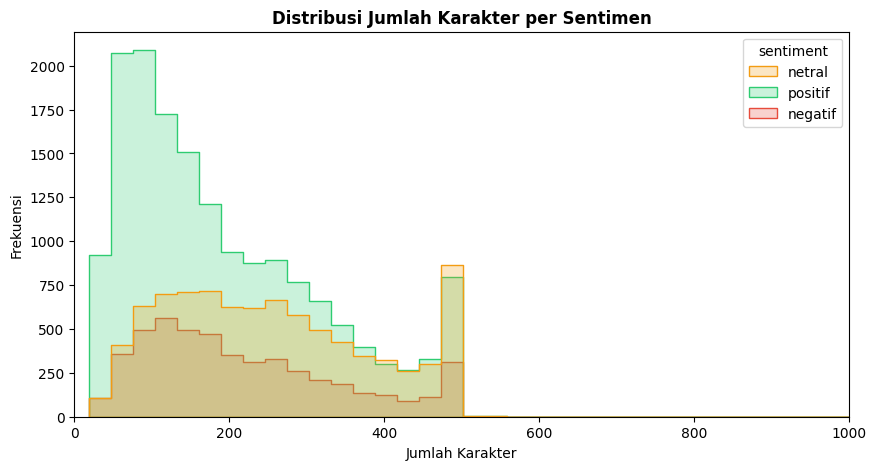

In [ ]:
print("\n" + "=" * 60)
print("EDA 7: DISTRIBUSI PANJANG KARAKTER (REVIEWS)")
print("=" * 60)

df['char_length'] = df['Review'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='char_length', hue='sentiment', element='step', palette=colors, bins=50)
plt.title('Distribusi Jumlah Karakter per Sentimen', fontweight='bold')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.xlim(0, 1000)
plt.show()


EDA 8: TOP BIGRAMS (PASANGAN KATA)


/tmp/ipykernel_909/948091038.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='viridis')


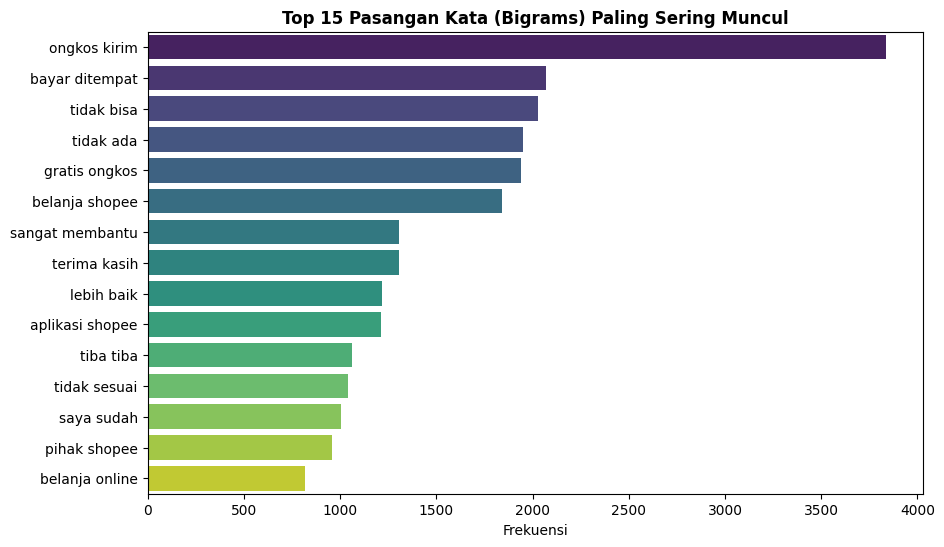

In [ ]:
print("\n" + "=" * 60)
print("EDA 8: TOP BIGRAMS (PASANGAN KATA)")
print("=" * 60)

from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_bigrams = get_top_bigrams(df['final_text'].dropna(), 15)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x, palette='viridis')
plt.title('Top 15 Pasangan Kata (Bigrams) Paling Sering Muncul', fontweight='bold')
plt.xlabel('Frekuensi')
plt.show()


EDA 9: DISTRIBUSI RATING BERDASARKAN SENTIMEN


/tmp/ipykernel_909/3752424634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='Score', data=df, palette=colors)


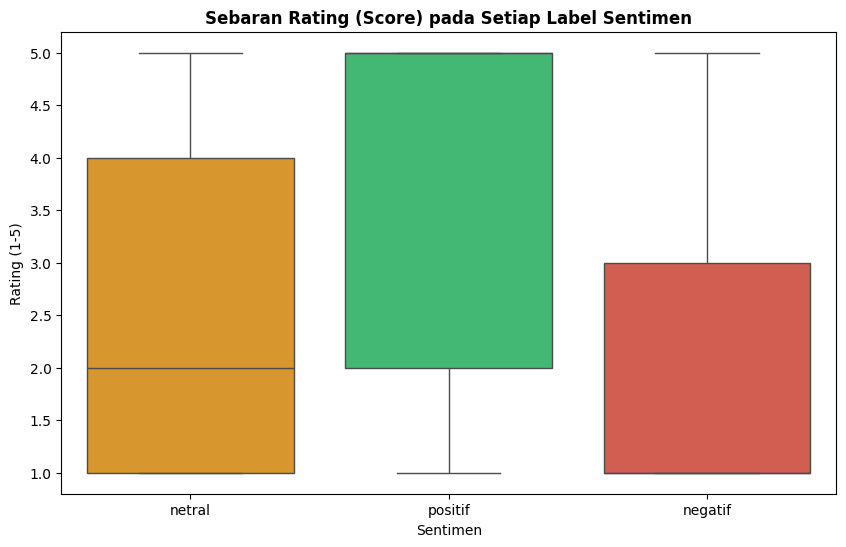

Detail rata-rata rating per sentimen:
sentiment
negatif    2.168297
netral     2.492318
positif    3.643344
Name: Score, dtype: float64


In [ ]:
print("\n" + "=" * 60)
print("EDA 9: DISTRIBUSI RATING BERDASARKAN SENTIMEN")
print("=" * 60)

plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='Score', data=df, palette=colors)
plt.title('Sebaran Rating (Score) pada Setiap Label Sentimen', fontweight='bold')
plt.xlabel('Sentimen')
plt.ylabel('Rating (1-5)')
plt.show()

print("Detail rata-rata rating per sentimen:")
print(df.groupby('sentiment')['Score'].mean())


EDA 10. ANALISIS PERSENTASE KATA UNIK PER SENTIMEN


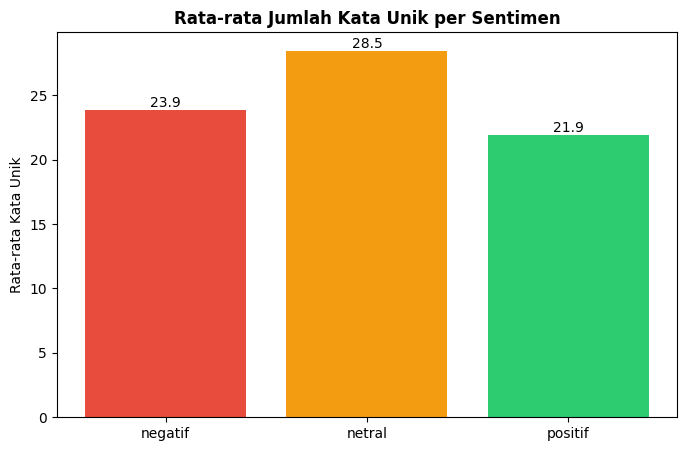

In [ ]:
print("\n" + "=" * 60)
print("EDA 10. ANALISIS PERSENTASE KATA UNIK PER SENTIMEN")
print("=" * 60)

def count_unique_words(text):
    return len(set(str(text).split()))

df['unique_word_count'] = df['final_text'].apply(count_unique_words)

avg_unique = df.groupby('sentiment')['unique_word_count'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_unique.index, avg_unique.values, color=[colors['negatif'], colors['netral'], colors['positif']])
plt.title('Rata-rata Jumlah Kata Unik per Sentimen', fontweight='bold')
plt.ylabel('Rata-rata Kata Unik')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.1f}', ha='center', va='bottom')

plt.show()

## 5. Feature Extraction

AHMAD JUL HADI (2301010019)

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.1 MB/s eta 0:00:00


In [ ]:
from collections import Counter
from gensim.models import Word2Vec
import numpy as np
import pandas as pd
import pickle
import json
import os

print("FEATURE EXTRACTION")

# DATA
texts = df['final_text'].dropna().astype(str).values
print(f"Jumlah dokumen: {len(texts):,}")

# TOKENIZATION
tokenized_texts = [text.split() for text in texts]
print("\nContoh tokenisasi:")
for i in range(min(3, len(tokenized_texts))):
    print(f"  {tokenized_texts[i][:10]}")

# WORD2VEC
print("\n--- Training Word2Vec ---")
embedding_dim = 128
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=embedding_dim,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=42
)
print("Word2Vec berhasil dilatih")

# VOCABULARY
all_words = []
for tokens in tokenized_texts:
    all_words.extend(tokens)

word_counts = Counter(all_words)
print(f"\nJumlah kata unik sebelum filtering: {len(word_counts):,}")

filtered_words = [(word, freq) for word, freq in word_counts.items() if freq >= 2]
print(f"Jumlah kata unik setelah filtering: {len(filtered_words):,}")

sorted_words = sorted(filtered_words, key=lambda x: x[1], reverse=True)
word_to_index = {word: idx + 1 for idx, (word, freq) in enumerate(sorted_words)}
index_to_word = {idx: word for word, idx in word_to_index.items()}
vocab_size = len(word_to_index) + 1

print(f"\nUkuran vocabulary: {vocab_size:,}")
print("\n10 Kata Paling Sering:")
for word, freq in sorted_words[:10]:
    print(f"  {word:15s} -> {freq:,}")

# TEXT TO SEQUENCE
def text_to_sequence(text):
    return [word_to_index[word] for word in text.split() if word in word_to_index]

sequences = [text_to_sequence(text) for text in texts]
print("\nContoh Sequence:")
for i in range(3):
    print(f"Teks     : {texts[i][:60]}...")
    print(f"Sequence : {sequences[i][:10]}")

# PADDING
print("\n--- Padding Sequence ---")
max_length = 100
def pad_sequence(seq):
    if len(seq) >= max_length:
        return seq[:max_length]
    return [0] * (max_length - len(seq)) + seq

padded_sequences = np.array([pad_sequence(seq) for seq in sequences])
print(f"Shape padded sequences: {padded_sequences.shape}")

# EMBEDDING MATRIX
print("\n--- Membuat Embedding Matrix ---")
embedding_matrix = np.zeros((vocab_size, embedding_dim))
found_words = 0
for word, idx in word_to_index.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found_words += 1

coverage = (found_words / (vocab_size - 1)) * 100
print(f"Coverage Word2Vec: {coverage:.2f}%")
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

# LABEL RATING
print("\n--- Label Rating ---")
def rating_to_sentiment(score):
    if score <= 2: return "negatif"
    elif score == 3: return "netral"
    else: return "positif"

df["rating_sentiment"] = df["Score"].apply(rating_to_sentiment)
print(df["rating_sentiment"].value_counts())

# LABEL ENCODING
print("\n--- Label Encoding ---")
label_mapping = {"negatif": 0, "netral": 1, "positif": 2}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

labels_lexicon = df["sentiment"].map(label_mapping).values
labels_rating = df["rating_sentiment"].map(label_mapping).values

print("\nDistribusi Label Lexicon:")
print(np.bincount(labels_lexicon))
print("\nDistribusi Label Rating:")
print(np.bincount(labels_rating))

# VALIDASI DATA
print("\n--- Validasi Vocabulary ---")
print("Max Token Index:", padded_sequences.max())
print("Vocabulary Size:", vocab_size)
assert padded_sequences.max() < vocab_size, "ERROR: Token index melebihi vocab_size"
print("Validasi berhasil")

FEATURE EXTRACTION
Jumlah dokumen: 29,974

Contoh tokenisasi:
  ['aplikasi', 'sudah', 'sangat', 'membantu', 'membeli', 'barang', 'tanpa', 'harus', 'keluar', 'rumah']
  ['notifikasinya', 'dibenerin', 'sering', 'muncul', 'pesanan', 'dikirim', 'waktu', 'dipencet', 'bahkan', 'kebuka']
  ['saya', 'suka', 'gratis', 'ongkos', 'kirim', 'diskon', 'tapi', 'kenapa', 'sekarang', 'harus']

--- Training Word2Vec ---
Word2Vec berhasil dilatih

Jumlah kata unik sebelum filtering: 25,616
Jumlah kata unik setelah filtering: 11,909

Ukuran vocabulary: 11,910

10 Kata Paling Sering:
  shopee          -> 21,130
  saya            -> 18,272
  tidak           -> 14,060
  bisa            -> 11,526
  ada             -> 11,519
  sudah           -> 10,507
  barang          -> 10,473
  tapi            -> 9,618
  belanja         -> 9,086
  aplikasi        -> 8,464

Contoh Sequence:
Teks     : aplikasi sudah sangat membantu membeli barang tanpa harus ke...
Sequence : [10, 6, 13, 80, 454, 7, 126, 64, 160, 158]
Teks  

In [ ]:
print("MENYIMPAN ARTIFACTS")

x_padded_path = os.path.join(output_dir, 'X_padded.npy')

y_lexicon_path = os.path.join(output_dir, 'y_lexicon.npy')

y_rating_path = os.path.join(output_dir, 'y_rating.npy')
embedding_matrix_path = os.path.join(output_dir, 'embedding_matrix.npy')
w2v_model_path = os.path.join(output_dir, 'word2vec.model')
tokenizer_path = os.path.join(output_dir, 'tokenizer.pkl')
metadata_path = os.path.join(output_dir, 'metadata.json')

np.save(x_padded_path, padded_sequences)
np.save(y_lexicon_path, labels_lexicon)
np.save(y_rating_path, labels_rating)
np.save(embedding_matrix_path, embedding_matrix)

print(f"Saved: y_lexicon.npy {labels_lexicon.shape}")
print(f"Saved: y_rating.npy {labels_rating.shape}")
print(f"Saved: X_padded.npy {padded_sequences.shape}")
print(f"Saved: y_labels.npy {labels_lexicon.shape}")
print(f"Saved: embedding_matrix.npy {embedding_matrix.shape}")

w2v_model.save(w2v_model_path)
print("Saved: word2vec.model")

tokenizer_data = {
    'word_to_index': word_to_index,
    'index_to_word': index_to_word,
    'vocab_size': vocab_size,
    'max_length': max_length,
    'embedding_dim': embedding_dim,
    'label_mapping': label_mapping,
    'reverse_label_mapping': reverse_label_mapping,
    'word2vec_used': True
}

with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer_data, f)
print("Saved: tokenizer.pkl")

metadata = {
    'vocab_size': vocab_size,
    'max_length': max_length,
    'embedding_dim': embedding_dim,
    'total_data': len(df),
    'label_mapping': label_mapping,
    'sentiment_distribution': sentiment_counts.to_dict(),
    'rating_distribution': rating_counts.to_dict(),
    'feature_extraction': 'Word2Vec',
    'word2vec_window': 5,
    'word2vec_min_count': 2,
    'word2vec_vector_size': embedding_dim
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved: metadata.json")

MENYIMPAN ARTIFACTS
Saved: y_lexicon.npy (29974,)
Saved: y_rating.npy (29974,)
Saved: X_padded.npy (29974, 100)
Saved: y_labels.npy (29974,)
Saved: embedding_matrix.npy (11910, 128)
Saved: word2vec.model
Saved: tokenizer.pkl
Saved: metadata.json


## 6. Model LSTM


MADE ARYA SUTHA WIJAYA (2301010030)

In [64]:
import os
import pickle
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("LOAD DATA")

# SEED
np.random.seed(42)
torch.manual_seed(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Device : {device}")

# LOAD FILE
output_dir = "/content/output"
if not os.path.exists(output_dir):
    output_dir = "."


X = np.load(os.path.join(output_dir,"X_padded.npy"))
y_lexicon = np.load(
    os.path.join(
        output_dir,
        "y_lexicon.npy"
    )
)

y_rating = np.load(
    os.path.join(
        output_dir,
        "y_rating.npy"
    )
)

# PILIH LABEL
USE_RATING_LABEL = False

if USE_RATING_LABEL:
    y = np.load(
        os.path.join(
            output_dir,
            "y_rating.npy"
        )
    )
    print("Menggunakan Label Rating")
else:
    y = np.load(
        os.path.join(
            output_dir,
            "y_lexicon.npy"
        )
    )
    print("Menggunakan Label Lexicon")

# EMBEDDING MATRIX
embedding_matrix = np.load(
    os.path.join(
        output_dir,
        "embedding_matrix.npy"
    )
)

# TOKENIZER
with open(
    os.path.join(
        output_dir,
        "tokenizer.pkl"
    ),
    "rb"
) as f:
    tokenizer_data = pickle.load(f)

vocab_size = tokenizer_data["vocab_size"]
max_length = tokenizer_data["max_length"]
embedding_dim = tokenizer_data["embedding_dim"]
word_to_index = tokenizer_data["word_to_index"]
reverse_label_mapping = tokenizer_data["reverse_label_mapping"]

# VALIDASI DATA
print("\nVALIDASI DATA")
print(f"X Shape          : {X.shape}")
print(f"y Shape          : {y.shape}")
print(f"Vocabulary Size  : {vocab_size}")
print(f"Embedding Shape  : {embedding_matrix.shape}")
print(f"Max Token Index  : {X.max()}")
print(f"Min Token Index  : {X.min()}")
print(f"Unique Label     : {np.unique(y)}")

assert X.max() < vocab_size
assert y.min() >= 0
assert y.max() <= 2

# TRAIN / TEST SPLIT
X_train_full, X_test, \
y_train_full, y_test, \
rating_train_full, rating_test = train_test_split(
    X,
    y,
    y_rating,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# TRAIN / VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# DISTRIBUSI DATA
print("\nDATA SPLIT")
print(f"Train      : {len(X_train):,}")
print(f"Validation : {len(X_val):,}")
print(f"Test       : {len(X_test):,}")

print("\nDistribusi Label")
print("Train :", np.bincount(y_train))
print("Val   :", np.bincount(y_val))
print("Test  :", np.bincount(y_test))

# CLASS WEIGHT
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass Weights")
print(class_weights)

# SUMMARY
print("\nDATA SIAP UNTUK TRAINING")
print(f"Train Shape : {X_train.shape}")
print(f"Val Shape   : {X_val.shape}")
print(f"Test Shape  : {X_test.shape}")


LOAD DATA
Device : cuda
Menggunakan Label Lexicon

VALIDASI DATA
X Shape          : (29974, 100)
y Shape          : (29974,)
Vocabulary Size  : 11910
Embedding Shape  : (11910, 128)
Max Token Index  : 11909
Min Token Index  : 0
Unique Label     : [0 1 2]

DATA SPLIT
Train      : 19,183
Validation : 4,796
Test       : 5,995

Distribusi Label
Train : [ 3141  5624 10418]
Val   : [ 785 1406 2605]
Test  : [ 982 1757 3256]

Class Weights
tensor([2.0358, 1.1370, 0.6138], device='cuda:0')

DATA SIAP UNTUK TRAINING
Train Shape : (19183, 100)
Val Shape   : (4796, 100)
Test Shape  : (5995, 100)


In [65]:
print("PERSIAPAN DATA PYTORCH")

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Batch size: {batch_size}")
print(f"Jumlah batch training: {len(train_loader)}")
print(f"Jumlah batch testing: {len(test_loader)}")

PERSIAPAN DATA PYTORCH
Batch size: 32
Jumlah batch training: 600
Jumlah batch testing: 188


In [66]:
import torch
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, n_layers=2, dropout=0.3, fc_dropout=0.4):
        super(SentimentLSTM, self).__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=False,
            padding_idx=0
        )

        embedding_dim = embedding_matrix.shape[1]
        self.embedding_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        self.fc1 = nn.Linear(hidden_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(fc_dropout)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        embedded = self.embedding_dropout(self.embedding(x))
        lstm_out, (hidden, cell) = self.lstm(embedded)

        last_hidden = hidden[-1]

        out = self.fc1(last_hidden)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

hidden_dim = 128
output_dim = 3
n_layers = 2
dropout = 0.3
fc_dropout = 0.4
learning_rate = 0.001
num_epochs = 20

model = SentimentLSTM(
    embedding_matrix,
    hidden_dim,
    output_dim,
    n_layers,
    dropout,
    fc_dropout
).to(device)

In [67]:
print("Embedding Matrix Shape:")
print(embedding_matrix.shape)

print("Vocabulary Size:")
print(vocab_size)

print("Max Token Index Train:")
print(np.max(X_train))

print("Max Token Index Test:")
print(np.max(X_test))

print("Unique Labels:")
print(np.unique(y_train))

print(class_weights)
print(torch.isnan(class_weights))

Embedding Matrix Shape:
(11910, 128)
Vocabulary Size:
11910
Max Token Index Train:
11909
Max Token Index Test:
11908
Unique Labels:
[0 1 2]
tensor([2.0358, 1.1370, 0.6138], device='cuda:0')
tensor([False, False, False], device='cuda:0')


In [68]:
# mengecek label yang digunakan untuk training
if USE_RATING_LABEL:
    print("TRAINING MENGGUNAKAN LABEL RATING")
else:
    print("TRAINING MENGGUNAKAN LABEL LEXICON")

TRAINING MENGGUNAKAN LABEL LEXICON


In [69]:
import copy
import time

print("TRAINING MODEL")

# Loss Function
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-5
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

# Early Stopping
patience = 4
patience_counter = 0

# Menyimpan history
train_losses = []
train_accs = []

val_losses = []
val_accs = []

# Best Model
best_val_acc = 0.0
best_epoch = 0
best_model_state = None

start_time = time.time()

print(f"Mulai Training {num_epochs} epoch\n")

for epoch in range(num_epochs):

    epoch_start = time.time()


    # TRAINING
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += batch_y.size(0)

        train_correct += (
            predicted == batch_y
        ).sum().item()

    avg_train_loss = (
        train_loss /
        len(train_loader)
    )

    avg_train_acc = (
        train_correct /
        train_total
    )

    # VALIDATION
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(
                outputs,
                batch_y
            )

            val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += batch_y.size(0)

            val_correct += (
                predicted == batch_y
            ).sum().item()

    avg_val_loss = (
        val_loss /
        len(val_loader)
    )

    avg_val_acc = (
        val_correct /
        val_total
    )

    # Simpan History
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    # Scheduler
    scheduler.step(avg_val_acc)

    # Simpan Best Model
    if avg_val_acc > best_val_acc:

        best_val_acc = avg_val_acc
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1

    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {avg_train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {avg_val_acc:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Early Stopping
    if patience_counter >= patience:

        print("\nEarly Stopping Aktif")
        break

# LOAD BEST MODEL
if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

# SIMPAN MODEL TERBAIK
if USE_RATING_LABEL:
    model_name = "best_model_rating.pth"
else:
    model_name = "best_model_lexicon.pth"
torch.save(
    model.state_dict(),
    model_name
)

# TRAINING SUMMARY
training_time = time.time() - start_time

print("\n" + "=" * 60)
print("TRAINING SELESAI")
print("=" * 60)
print(f"Best Epoch     : {best_epoch}")
print(f"Best Val Acc   : {best_val_acc:.4f}")
print(f"Training Time  : {training_time/60:.2f} menit")

TRAINING MODEL
Mulai Training 20 epoch

Epoch [01/20] | Train Loss: 0.8113 | Train Acc: 0.6210 | Val Loss: 0.5556 | Val Acc: 0.7905 | LR: 0.001000 | Time: 3.2s
Epoch [02/20] | Train Loss: 0.5208 | Train Acc: 0.7904 | Val Loss: 0.4155 | Val Acc: 0.8309 | LR: 0.001000 | Time: 3.2s
Epoch [03/20] | Train Loss: 0.3853 | Train Acc: 0.8499 | Val Loss: 0.3788 | Val Acc: 0.8328 | LR: 0.001000 | Time: 3.6s
Epoch [04/20] | Train Loss: 0.3043 | Train Acc: 0.8830 | Val Loss: 0.4038 | Val Acc: 0.8480 | LR: 0.001000 | Time: 3.2s
Epoch [05/20] | Train Loss: 0.2447 | Train Acc: 0.9106 | Val Loss: 0.4165 | Val Acc: 0.8601 | LR: 0.001000 | Time: 3.0s
Epoch [06/20] | Train Loss: 0.2139 | Train Acc: 0.9234 | Val Loss: 0.6115 | Val Acc: 0.8084 | LR: 0.001000 | Time: 3.2s
Epoch [07/20] | Train Loss: 0.1735 | Train Acc: 0.9405 | Val Loss: 0.5001 | Val Acc: 0.8707 | LR: 0.001000 | Time: 3.2s
Epoch [08/20] | Train Loss: 0.1431 | Train Acc: 0.9490 | Val Loss: 0.5325 | Val Acc: 0.8695 | LR: 0.001000 | Time: 3.0s


In [70]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

print("REBUILD TEST SET")

# Load label
y_lexicon = np.load(
    os.path.join(output_dir, "y_lexicon.npy")
)

y_rating = np.load(
    os.path.join(output_dir, "y_rating.npy")
)

# TEST SET LEXICON
_, X_test_lexicon, _, y_test_lexicon = train_test_split(
    X,
    y_lexicon,
    test_size=0.20,
    random_state=42,
    stratify=y_lexicon
)

# TEST SET RATING
_, X_test_rating, _, y_test_rating = train_test_split(
    X,
    y_rating,
    test_size=0.20,
    random_state=42,
    stratify=y_rating
)

# DATALOADER LEXICON
test_loader_lexicon = DataLoader(
    TensorDataset(
        torch.LongTensor(X_test_lexicon),
        torch.LongTensor(y_test_lexicon)
    ),
    batch_size=32,
    shuffle=False
)

# DATALOADER RATING
test_loader_rating = DataLoader(
    TensorDataset(
        torch.LongTensor(X_test_rating),
        torch.LongTensor(y_test_rating)
    ),
    batch_size=32,
    shuffle=False
)

print("Lexicon Test :", len(y_test_lexicon))
print("Rating Test  :", len(y_test_rating))

REBUILD TEST SET
Lexicon Test : 5995
Rating Test  : 5995


In [71]:
def load_saved_model(model_path):
    model_obj = SentimentLSTM(
        embedding_matrix,
        hidden_dim,
        output_dim,
        n_layers,
        dropout,
        fc_dropout
    ).to(device)

    # Memuat weights model
    model_obj.load_state_dict(torch.load(model_path, map_location=device))
    model_obj.eval()
    return model_obj

def evaluate_model(model_obj, dataloader, y_true, title):
    model_obj.eval()
    all_preds = []

    with torch.no_grad():
        for batch_x, _ in dataloader:
            batch_x = batch_x.to(device)
            outputs = model_obj(batch_x)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())

    all_preds = np.array(all_preds)

    print(f"\n--- EVALUASI MODEL {title.upper()} ---")
    print(classification_report(y_true, all_preds, target_names=["Negatif", "Netral", "Positif"]))

    return {
        "Accuracy": accuracy_score(y_true, all_preds),
        "Precision": precision_score(y_true, all_preds, average='weighted'),
        "Recall": recall_score(y_true, all_preds, average='weighted'),
        "F1": f1_score(y_true, all_preds, average='weighted'),
        "CM": confusion_matrix(y_true, all_preds)
    }

# Memuat model yang telah disimpan
model_lexicon = load_saved_model("best_model_lexicon.pth")

if os.path.exists("best_model_rating.pth"):
    model_rating = load_saved_model("best_model_rating.pth")
else:
    print("best_model_rating.pth tidak ditemukan. Menggunakan model lexicon sebagai placeholder.")
    model_rating = model_lexicon

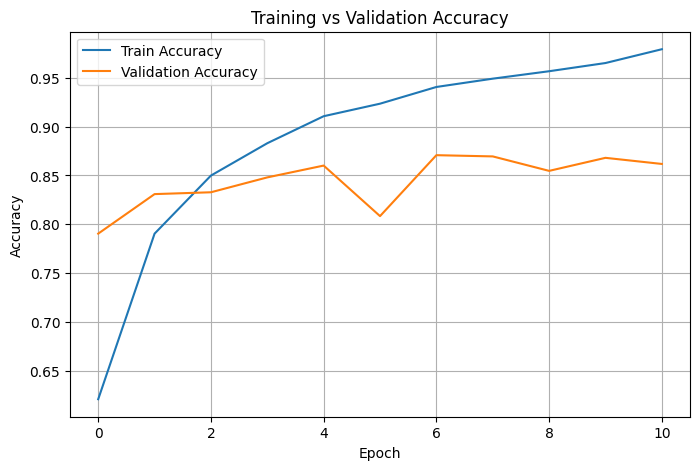

In [72]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

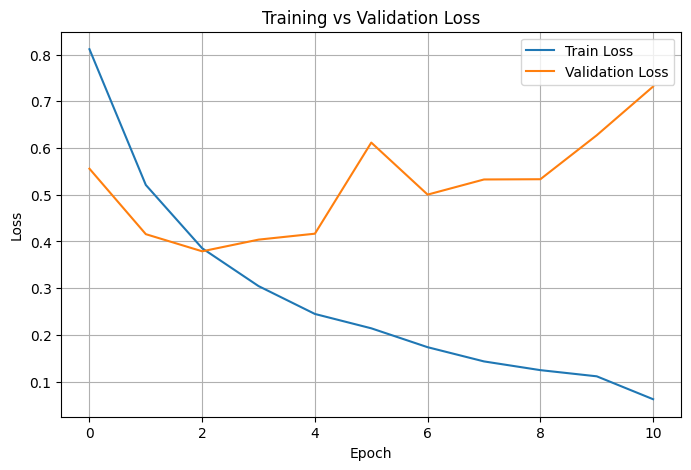

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
result_lexicon = evaluate_model(
    model_lexicon,
    test_loader_lexicon,
    y_test_lexicon,
    "Lexicon"
)


--- EVALUASI MODEL LEXICON ---
              precision    recall  f1-score   support

     Negatif       0.90      0.79      0.84       982
      Netral       0.79      0.80      0.80      1757
     Positif       0.92      0.95      0.93      3256

    accuracy                           0.88      5995
   macro avg       0.87      0.85      0.86      5995
weighted avg       0.88      0.88      0.88      5995



In [74]:
result_rating = evaluate_model(
    model_rating,
    test_loader_rating,
    y_test_rating,
    "Rating"
)


--- EVALUASI MODEL RATING ---
              precision    recall  f1-score   support

     Negatif       0.79      0.75      0.77      2673
      Netral       0.18      0.29      0.23       509
     Positif       0.86      0.81      0.83      2813

    accuracy                           0.74      5995
   macro avg       0.61      0.62      0.61      5995
weighted avg       0.77      0.74      0.75      5995



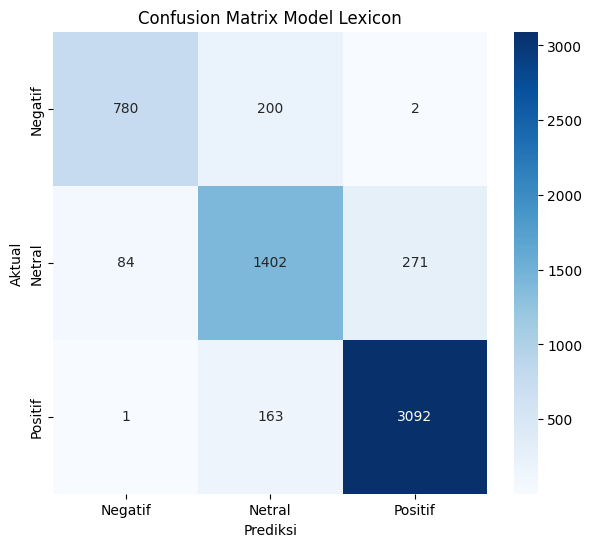

In [75]:
plt.figure(figsize=(7,6))

sns.heatmap(
    result_lexicon["CM"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ],
    yticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ]
)
plt.title("Confusion Matrix Model Lexicon")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

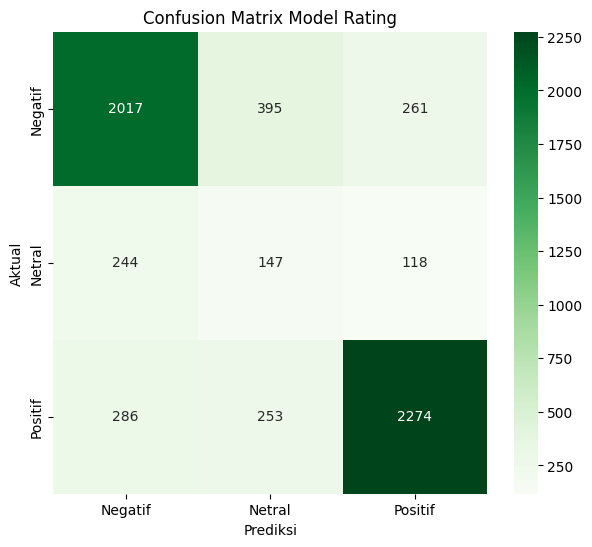

In [76]:
plt.figure(figsize=(7,6))

sns.heatmap(
    result_rating["CM"],
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ],
    yticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ]
)

plt.title("Confusion Matrix Model Rating")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [77]:
comparison = pd.DataFrame({

    "Model":[
        "Lexicon",
        "Rating"
    ],

    "Accuracy":[
        result_lexicon["Accuracy"],
        result_rating["Accuracy"]
    ],

    "Precision":[
        result_lexicon["Precision"],
        result_rating["Precision"]
    ],

    "Recall":[
        result_lexicon["Recall"],
        result_rating["Recall"]
    ],

    "F1 Score":[
        result_lexicon["F1"],
        result_rating["F1"]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Lexicon,0.879733,0.879565,0.879733,0.878953
1,Rating,0.740284,0.770983,0.740284,0.754130


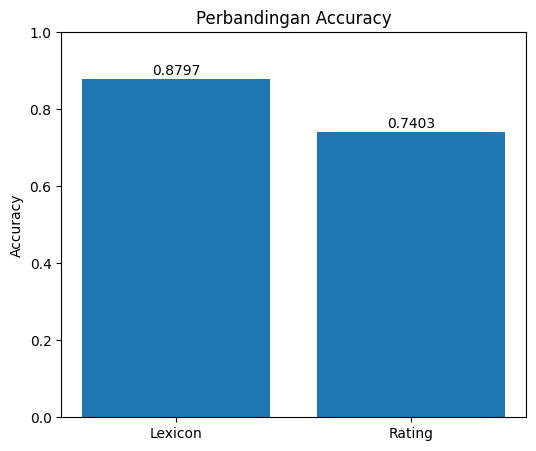

In [79]:
plt.figure(figsize=(6,5))

models = [
    "Lexicon",
    "Rating"
]

accuracy = [
    result_lexicon["Accuracy"],
    result_rating["Accuracy"]
]

plt.bar(
    models,
    accuracy
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy")

for i, v in enumerate(accuracy):

    plt.text(
        i,
        v + 0.01,
        f"{v:.4f}",
        ha="center"
    )

plt.show()

## 7. Inference  

In [85]:

def predict_sentiment(text, target_model):
    global word_to_index, reverse_label_mapping
    # Load tokenizer dynamically to ensure we are using the correct mappings
    if 'word_to_index' not in globals() or len(word_to_index) != 11909:
        try:
            import pickle
            tok_path = "tokenizer.pkl" if os.path.exists("tokenizer.pkl") else "../tokenizer.pkl"
            with open(tok_path, "rb") as f:
                tok_data = pickle.load(f)
            word_to_index = tok_data["word_to_index"]
            reverse_label_mapping = tok_data["reverse_label_mapping"]
        except Exception as e:
            pass
    text_clean = cleaning_text(text)
    text_cf = case_folding(text_clean)
    text_slang = fix_slangwords(text_cf)
    tokens = tokenizing(text_slang)
    tokens_final = stopword_removal(tokens)
    clean_text = ' '.join(tokens_final)

    seq = [word_to_index[w] for w in tokens_final if w in word_to_index]
    padded_seq = pad_sequence(seq)

    target_model.eval()
    input_tensor = torch.LongTensor([padded_seq]).to(device)

    with torch.no_grad():
        outputs = target_model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    label = reverse_label_mapping[predicted.item()]
    return label, confidence.item(), clean_text, seq

print("PILIH MODEL UNTUK TESTING:")
print("1. Model Lexicon (best_model_lexicon.pth)")
print("2. Model Rating (best_model_rating.pth)")
pilihan = input("Masukkan pilihan (1/2): ")

if pilihan == '1':
    current_model = model_lexicon
    model_name_label = "LEXICON"
else:
    current_model = model_rating
    model_name_label = "RATING"

current_model.to(device)
print(f"\n--- MENGGUNAKAN MODEL: {model_name_label} ---")
print("Ketik 'exit' untuk berhenti.")

while True:
    user_input = input("\nMasukkan ulasan baru: ")
    if user_input.lower() == 'exit':
        break

    if user_input.strip():
        try:
            sentiment, confidence, cleaned, sequence = predict_sentiment(user_input, current_model)
            print(f"\nHASIL ({model_name_label})")
            print("Text Asli     :", user_input)
            print("Preprocessing :", cleaned)
            print("Sequence      :", sequence)
            print("Sentimen      :", sentiment.upper())
            print(f"Confidence    : {confidence*100:.2f}%")
        except Exception as e:
            print(f"Terjadi kesalahan: {e}")
    else:
        print("Input tidak boleh kosong")


PILIH MODEL UNTUK TESTING:
1. Model Lexicon (best_model_lexicon.pth)
2. Model Rating (best_model_rating.pth)
Masukkan pilihan (1/2): 1

--- MENGGUNAKAN MODEL: LEXICON ---
Ketik 'exit' untuk berhenti.

Masukkan ulasan baru: aplikasinya bagus baget saya suka

HASIL (LEXICON)
Text Asli     : aplikasinya bagus baget saya suka
Preprocessing : aplikasinya bagus baget saya suka
Sequence      : [104, 27, 2772, 2, 50]
Sentimen      : POSITIF
Confidence    : 98.35%

Masukkan ulasan baru: aplikasinya jelek saya tidak suka

HASIL (LEXICON)
Text Asli     : aplikasinya jelek saya tidak suka
Preprocessing : aplikasinya jelek saya tidak suka
Sequence      : [104, 224, 2, 3, 50]
Sentimen      : NEGATIF
Confidence    : 98.98%

Masukkan ulasan baru: aplikasi shopee bagus tapi kurang cepat pengirimannya

HASIL (LEXICON)
Text Asli     : aplikasi shopee bagus tapi kurang cepat pengirimannya
Preprocessing : aplikasi shopee bagus tapi kurang cepat pengirimannya
Sequence      : [10, 1, 27, 8, 120, 62, 171]
Sen